### Dataset Description

A Chinese automobile company Geely Auto aspires to enter the US market by setting up their manufacturing unit there and producing cars locally to give competition to their US and European counterparts.

They have contracted an automobile consulting company to understand the factors on which the pricing of cars depends. Specifically, they want to understand the factors affecting the pricing of cars in the American market, since those may be very different from the Chinese market. The company wants to know:

- Which variables are significant in predicting the price of a car
- How well those variables describe the price of a car

Based on various market surveys, the consulting firm has gathered a large data set of different types of cars across the America market.


In [ ]:
# Import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

![image.png](attachment:777f51a4-eeae-4f74-8eb4-8ad4555646aa.png)

### Objective

We are required to model the price of cars with the available independent variables. It will be used by the management to understand how exactly the prices vary with the independent variables. They can accordingly manipulate the design of the cars, the business strategy etc. to meet certain price levels. Further, the model will be a good way for management to understand the pricing dynamics of a new market.

In [ ]:
# Write code here
df = pd.read_csv('CarPrice_Assignment.csv')


In [ ]:
print(df.head(10))

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   
5       6          2                  audi fox      gas        std        two   
6       7          1                audi 100ls      gas        std       four   
7       8          1                 audi 5000      gas        std       four   
8       9          1                 audi 4000      gas      turbo       four   
9      10          0       audi 5000s (diesel)      gas      turbo        two   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          f

In [ ]:
'''The Features that are possibly uninformative are:
    1. car_ID: This is because it is purely a unique identifier and has no intrinsic relationship with the price.
    2. CarName: While the brand can influence the price, this field is a mix of brand and model names. It might introduce noise or inconsistencies due to formatting or spelling errors
    3. Symboling: This insurance risk rating may not have a direct causal relationship with the car price. It could reflect perceived safety but might not be directly linked to market dynamics.'''

'The Features that are possibly uninformative are:\n    1. car_ID: This is because it is purely a unique identifier and has no intrinsic relationship with the price.\n    2. CarName: While the brand can influence the price, this field is a mix of brand and model names. It might introduce noise or inconsistencies due to formatting or spelling errors\n    3. Symboling: This insurance risk rating may not have a direct causal relationship with the car price. It could reflect perceived safety but might not be directly linked to market dynamics.'

#### Data Cleaning and Exploratory Data Analysis

In [ ]:
# Write code here
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


In [ ]:
df = df.drop(columns=['CarName', 'fuelsystem', 'cylindernumber'])
print(df.head())

   car_ID  symboling fueltype aspiration doornumber      carbody drivewheel  \
0       1          3      gas        std        two  convertible        rwd   
1       2          3      gas        std        two  convertible        rwd   
2       3          1      gas        std        two    hatchback        rwd   
3       4          2      gas        std       four        sedan        fwd   
4       5          2      gas        std       four        sedan        4wd   

  enginelocation  wheelbase  carlength  ...  enginetype  enginesize  \
0          front       88.6      168.8  ...        dohc         130   
1          front       88.6      168.8  ...        dohc         130   
2          front       94.5      171.2  ...        ohcv         152   
3          front       99.8      176.6  ...         ohc         109   
4          front       99.4      176.6  ...         ohc         136   

   boreratio stroke  compressionratio  horsepower  peakrpm  citympg  \
0       3.47   2.68        

In [ ]:
df = df[df['price'].notnull()]
missing_values = df.isnull().sum()
missing_columns = missing_values[missing_values > 0].index

for col in missing_columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

print(df.isnull().sum())

car_ID              0
symboling           0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
enginesize          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


In [ ]:
descriptive_stats = df.describe()

print(descriptive_stats)

           car_ID   symboling   wheelbase   carlength    carwidth   carheight  \
count  205.000000  205.000000  205.000000  205.000000  205.000000  205.000000   
mean   103.000000    0.834146   98.756585  174.049268   65.907805   53.724878   
std     59.322565    1.245307    6.021776   12.337289    2.145204    2.443522   
min      1.000000   -2.000000   86.600000  141.100000   60.300000   47.800000   
25%     52.000000    0.000000   94.500000  166.300000   64.100000   52.000000   
50%    103.000000    1.000000   97.000000  173.200000   65.500000   54.100000   
75%    154.000000    2.000000  102.400000  183.100000   66.900000   55.500000   
max    205.000000    3.000000  120.900000  208.100000   72.300000   59.800000   

        curbweight  enginesize   boreratio      stroke  compressionratio  \
count   205.000000  205.000000  205.000000  205.000000        205.000000   
mean   2555.565854  126.907317    3.329756    3.255415         10.142537   
std     520.680204   41.642693    0.270844

#### Univariate Analysis

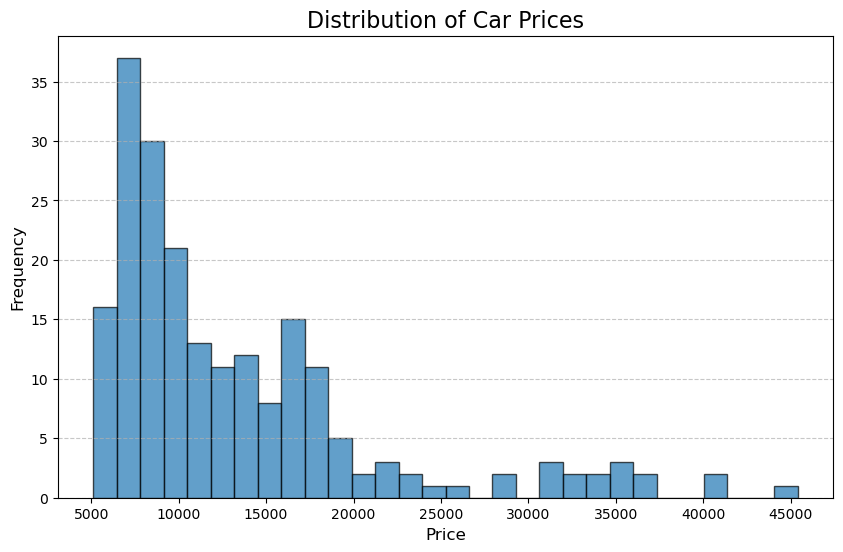

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of Car Prices', fontsize=16)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

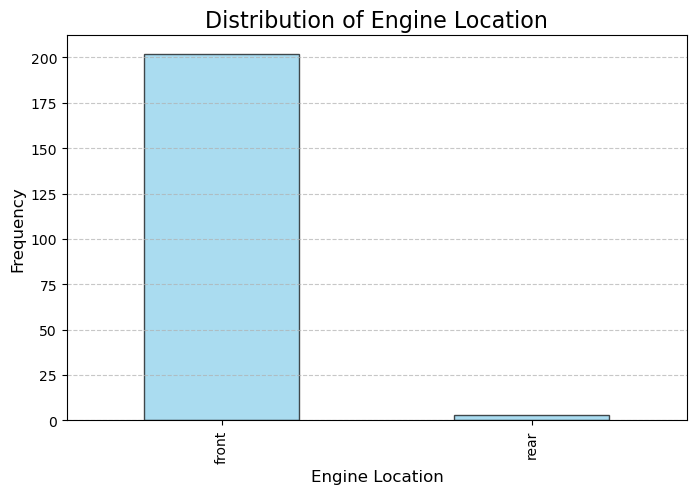

In [ ]:
plt.figure(figsize=(8, 5))
df['enginelocation'].value_counts().plot(kind='bar', color='skyblue', edgecolor='k', alpha=0.7)
plt.title('Distribution of Engine Location', fontsize=16)
plt.xlabel('Engine Location', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
print(df['enginelocation'].value_counts())
df['enginelocation'] = df['enginelocation'].map({'front': 0, 'rear': 1})
print(df['enginelocation'].value_counts())

enginelocation
front    202
rear       3
Name: count, dtype: int64
enginelocation
0    202
1      3
Name: count, dtype: int64


#### Bivariate Analysis

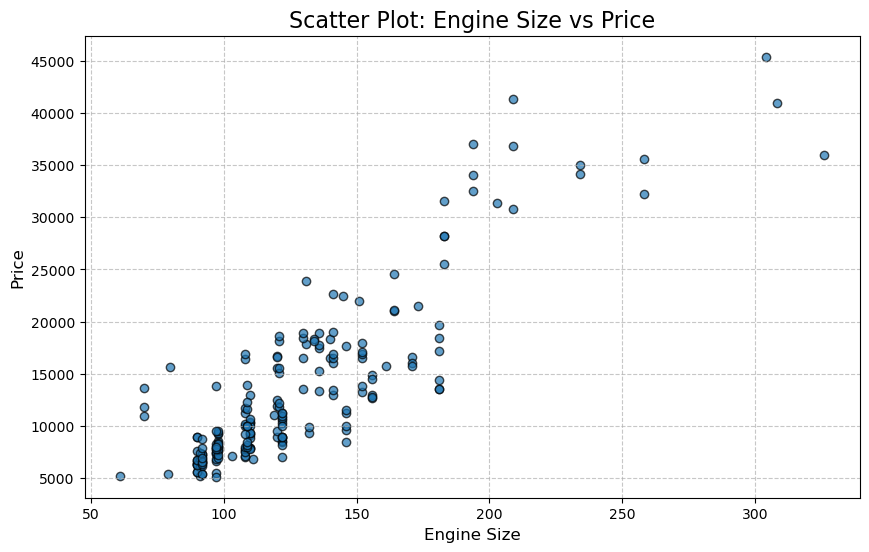

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['enginesize'], df['price'], alpha=0.7, edgecolor='k')
plt.title('Scatter Plot: Engine Size vs Price', fontsize=16)
plt.xlabel('Engine Size', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(linestyle='--', alpha=0.7)
plt.show()

In [ ]:
'''We observe three main things:
    1. 	Positive Correlation: There is a clear positive correlation between engine size (enginesize) and car price (price). As the engine size increases, the price tends to increase as well.
	2.	Non-Linear Relationship: The relationship appears to be slightly non-linear. The rate of price increase may not be constant across the range of engine sizes. For smaller engine sizes, price changes are moderate, but for larger engines, prices rise more steeply.
	3.	Clusters: There might be clusters of data points, potentially corresponding to different car segments (e.g., economy, mid-range, luxury).'''

'We observe three main things:\n    1. \tPositive Correlation: There is a clear positive correlation between engine size (enginesize) and car price (price). As the engine size increases, the price tends to increase as well.\n\t2.\tNon-Linear Relationship: The relationship appears to be slightly non-linear. The rate of price increase may not be constant across the range of engine sizes. For smaller engine sizes, price changes are moderate, but for larger engines, prices rise more steeply.\n\t3.\tClusters: There might be clusters of data points, potentially corresponding to different car segments (e.g., economy, mid-range, luxury).'

#### Data Preparation

In [ ]:
original_columns = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype']

df = pd.get_dummies(df, columns=original_columns, drop_first=True)

for col in original_columns:
    assert col not in df.columns, f"Column {col} should have been removed after one-hot encoding"

encoded_columns = [col for col in df.columns if any(oc in col for oc in original_columns)]
for col in encoded_columns:
    assert set(df[col].unique()).issubset({0, 1}), f"Column {col} contains non-binary values"

print(df.head())

   car_ID  symboling  wheelbase  carlength  carwidth  carheight  curbweight  \
0       1          3       88.6      168.8      64.1       48.8        2548   
1       2          3       88.6      168.8      64.1       48.8        2548   
2       3          1       94.5      171.2      65.5       52.4        2823   
3       4          2       99.8      176.6      66.2       54.3        2337   
4       5          2       99.4      176.6      66.4       54.3        2824   

   enginesize  boreratio  stroke  ...  carbody_wagon  drivewheel_fwd  \
0         130       3.47    2.68  ...          False           False   
1         130       3.47    2.68  ...          False           False   
2         152       2.68    3.47  ...          False           False   
3         109       3.19    3.40  ...          False            True   
4         136       3.19    3.40  ...          False           False   

   drivewheel_rwd  enginelocation_1  enginetype_dohcv  enginetype_l  \
0            True    

In [ ]:
from sklearn.preprocessing import MinMaxScaler

columns_to_normalize = ['wheelbase', 'carlength', 'carwidth', 'carheight',
                        'curbweight', 'enginesize', 'horsepower', 'peakrpm']

scaler = MinMaxScaler()

df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

print(df[columns_to_normalize].head())

   wheelbase  carlength  carwidth  carheight  curbweight  enginesize  \
0   0.058309   0.413433  0.316667   0.083333    0.411171    0.260377   
1   0.058309   0.413433  0.316667   0.083333    0.411171    0.260377   
2   0.230321   0.449254  0.433333   0.383333    0.517843    0.343396   
3   0.384840   0.529851  0.491667   0.541667    0.329325    0.181132   
4   0.373178   0.529851  0.508333   0.541667    0.518231    0.283019   

   horsepower   peakrpm  
0    0.262500  0.346939  
1    0.262500  0.346939  
2    0.441667  0.346939  
3    0.225000  0.551020  
4    0.279167  0.551020  


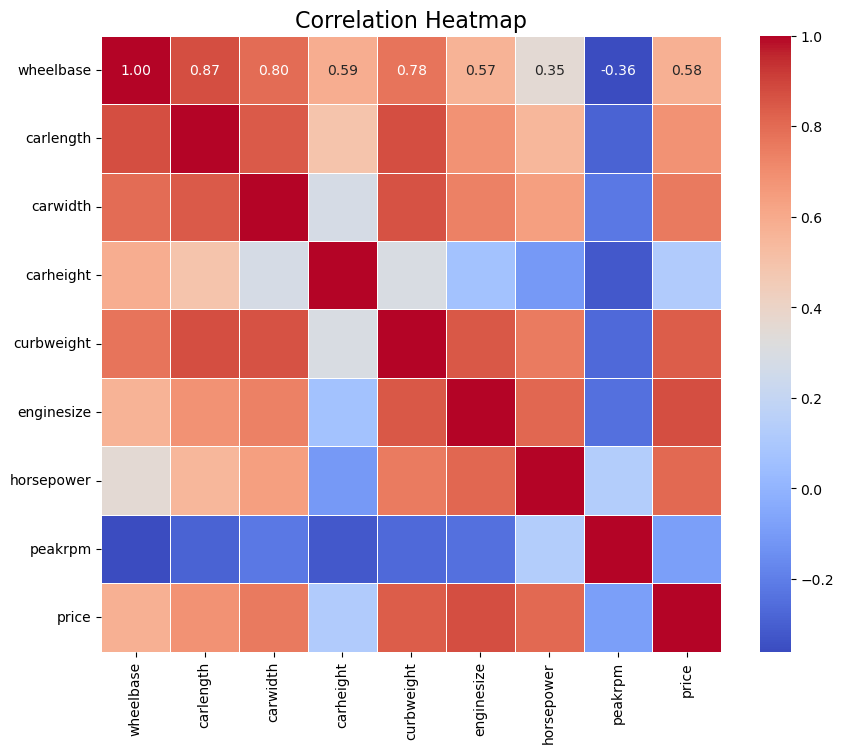

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = ['wheelbase', 'carlength', 'carwidth', 'carheight',
                     'curbweight', 'enginesize', 'horsepower', 'peakrpm', 'price']

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [ ]:
''''There are two main features like this:
    1. 	carheight: The correlation value is close to zero (weak correlation), indicating that car height doesn't significantly influence the price in a linear relationship.
	2.	peakrpm: Displays a weak negative correlation with price. This indicates that changes in peak RPM have minimal or no significant impact on the price in a linear sense.'''

"'There are two main features like this:\n    1. \tcarheight: The correlation value is close to zero (weak correlation), indicating that car height doesn't significantly influence the price in a linear relationship.\n\t2.\tpeakrpm: Displays a weak negative correlation with price. This indicates that changes in peak RPM have minimal or no significant impact on the price in a linear sense."

#### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)

print(f"Training data size: {train_df.shape}")
print(f"Test data size: {test_df.shape}")

Training data size: (153, 32)
Test data size: (52, 32)


In [ ]:
columns_to_drop = ['price', 'symboling', 'car_ID']

train_x = train_df.drop(columns=columns_to_drop)
train_y = train_df['price']
test_x = test_df.drop(columns=columns_to_drop)
test_y = test_df['price']

print(f"Training inputs shape: {train_x.shape}")
print(f"Training targets shape: {train_y.shape}")
print(f"Testing inputs shape: {test_x.shape}")
print(f"Testing targets shape: {test_y.shape}")

Training inputs shape: (153, 29)
Training targets shape: (153,)
Testing inputs shape: (52, 29)
Testing targets shape: (52,)


#### Machine Learning

In [ ]:
import statsmodels.api as sm

train_x = train_x.astype(int)
test_x = test_x.astype(int)

train_x = train_x.loc[:, ~train_x.columns.duplicated()]

train_x = sm.add_constant(train_x)

model = sm.OLS(train_y, train_x).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.791
Method:                 Least Squares   F-statistic:                     26.07
Date:                Wed, 04 Dec 2024   Prob (F-statistic):           8.67e-38
Time:                        23:06:47   Log-Likelihood:                -1457.3
No. Observations:                 153   AIC:                             2963.
Df Residuals:                     129   BIC:                             3035.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              3.841e+04   1.41e+0

In [ ]:
test_x = sm.add_constant(test_x)

predictions = model.predict(test_x)

print(predictions.head(10))

15     21779.107819
9      14684.313624
100     9815.291050
132    12219.290254
68     22392.692779
95      5171.765544
159     4907.569511
162     9906.498626
147     8085.949585
182     6228.331381
dtype: float64


In [ ]:
'''Five Variables:
    1. enginesize: It is a likely a significant variable with a very low p-value. As enginesize increases, the price of the car also increases significantly, which makes sense since larger engines typically lead to higher costs.
    2. horsepower: It is likely significant with a low p-value. Cars with higher horsepower are generally more powerful and expensive, contributing significantly to the price.
    3. carheight: It is likely not significant (higher p-value). The height of a car might not have a direct or substantial impact on its price. This variable could be excluded in a simplified model.
    4. enginelocation_rear: It is likely significant with a low p-value. Cars with rear engines are often luxury or performance vehicles, leading to a notable impact on price.
    5. citympg: It is Likely not significant (higher p-value). While fuel efficiency (citympg) might influence consumer choice, it may not directly drive the price as strongly as other variables like engine size or brand.'''

'Five Variables:\n    1. enginesize: It is a likely a significant variable with a very low p-value. As enginesize increases, the price of the car also increases significantly, which makes sense since larger engines typically lead to higher costs.\n    2. horsepower: It is likely significant with a low p-value. Cars with higher horsepower are generally more powerful and expensive, contributing significantly to the price.\n    3. carheight: It is likely not significant (higher p-value). The height of a car might not have a direct or substantial impact on its price. This variable could be excluded in a simplified model.\n    4. enginelocation_rear: It is likely significant with a low p-value. Cars with rear engines are often luxury or performance vehicles, leading to a notable impact on price.\n    5. citympg: It is Likely not significant (higher p-value). While fuel efficiency (citympg) might influence consumer choice, it may not directly drive the price as strongly as other variables li

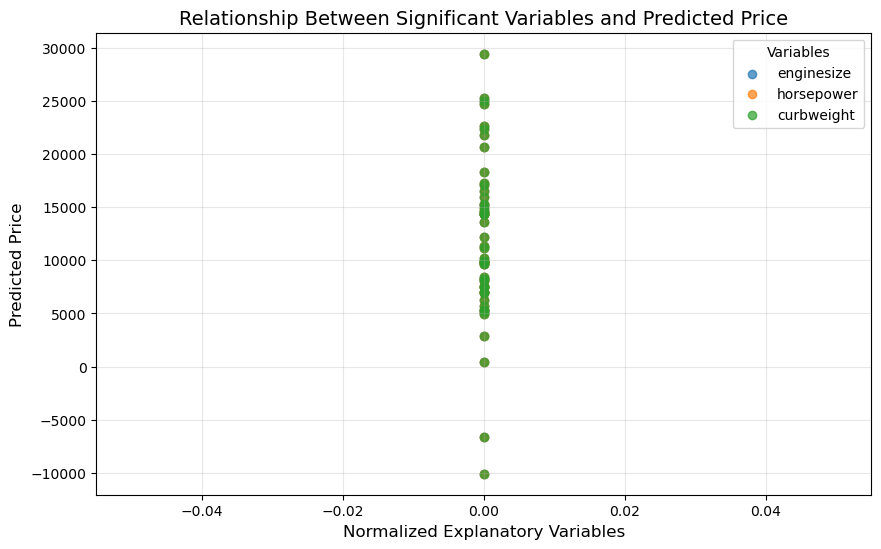

In [ ]:
significant_vars = ['enginesize', 'horsepower', 'curbweight']

plt.figure(figsize=(10, 6))
for var in significant_vars:
    plt.scatter(test_x[var], predictions, alpha=0.7, label=var)

plt.xlabel('Normalized Explanatory Variables', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)
plt.title('Relationship Between Significant Variables and Predicted Price', fontsize=14)
plt.legend(title="Variables")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Write code here
def calculateR2score(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)

    mean_actual = np.mean(actual)

    tss = np.sum((actual - mean_actual) ** 2)

    rss = np.sum((actual - predicted) ** 2)

    r2_score = 1 - (rss / tss)

    return r2_score

In [ ]:
r2_score = calculateR2score(test_y, predictions)

print(f"R^2 Score for the model: {r2_score}")

R^2 Score for the model: 0.5899342512424625


In [ ]:
def optimal_params(X, y):
    X = np.array(X)
    y = np.array(y)

    XT_X = np.dot(X.T, X)

    XT_X_pinv = np.linalg.pinv(XT_X)

    # Compute X^T * y
    XT_y = np.dot(X.T, y)

    theta = np.dot(XT_X_pinv, XT_y)

    return theta

In [ ]:
train_X = sm.add_constant(train_x.loc[:, ~train_x.columns.duplicated()])
train_y = np.array(train_y)

theta = optimal_params(train_X, train_y)

print("Optimal Parameters (Theta):")
print(theta)

test_X = sm.add_constant(test_x.loc[:, ~test_x.columns.duplicated()])

predictions_ols = np.dot(test_X, theta)

print("Predictions on Test Dataset:")
print(predictions_ols[:10])

Optimal Parameters (Theta):
[ 3.84052168e+04  2.10984652e-08  1.31912403e-09  5.87661401e+03
 -1.56589691e-10  1.29225096e+04  6.91286932e+03 -1.38025046e+03
 -3.28626250e+02  2.68642992e+02  5.87661401e+03 -1.00178006e-10
 -1.77435416e+02 -5.85907838e+02 -2.26660753e+03  6.61090054e+00
 -1.07796385e+03 -7.87359467e+02 -3.81602447e+03 -2.44928500e+03
 -4.77894134e+03  1.40692566e+03  4.38805879e+03  1.53499157e+04
  5.87661401e+03 -2.00533520e+03  2.40815005e+03  2.98601344e+02
  6.19773609e+03 -2.77903266e+03]
Predictions on Test Dataset:
[21779.10781873 14684.31362444  9815.29105032 12219.29025363
 22392.69277899  5171.76554391  4907.56951105  9906.49862559
  8085.94958531  6228.33138087]


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
import numpy as np

train_X = train_x.loc[:, ~train_x.columns.duplicated()]
test_X = test_x.loc[:, ~test_x.columns.duplicated()]
train_X = np.array(train_X)
test_X = np.array(test_X)
train_y = np.array(train_y)
test_y = np.array(test_y)

ridge = Ridge()
alpha_values = np.logspace(-4, 4, 50)
param_grid = {'alpha': alpha_values}

grid_search = GridSearchCV(estimator=ridge, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(train_X, train_y)

optimal_alpha = grid_search.best_params_['alpha']
best_model = grid_search.best_estimator_

predictions = best_model.predict(test_X)
rmse = np.sqrt(mean_squared_error(test_y, predictions))

print(f"Optimal Alpha: {optimal_alpha}")
print(f"RMSE on Test Set: {rmse}")

Optimal Alpha: 0.3906939937054613
RMSE on Test Set: 5321.213441865618


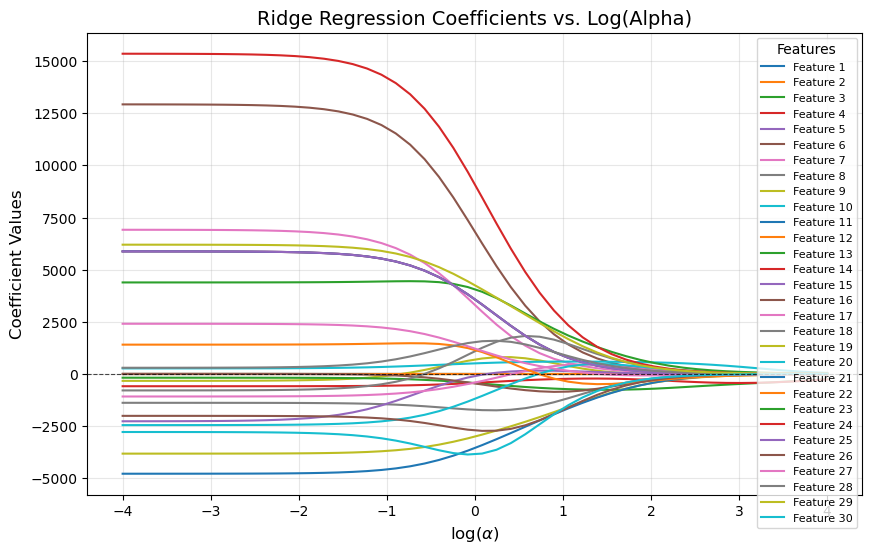

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge

alpha_values = np.logspace(-4, 4, 50)
log_alpha_values = np.log10(alpha_values)

coefficients = []

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_X, train_y)
    coefficients.append(ridge.coef_)

coefficients = np.array(coefficients)

plt.figure(figsize=(10, 6))
for i in range(coefficients.shape[1]):  # Iterate over each feature
    plt.plot(log_alpha_values, coefficients[:, i], label=f'Feature {i+1}')

plt.xlabel(r'$\log(\alpha)$', fontsize=12)
plt.ylabel('Coefficient Values', fontsize=12)
plt.title('Ridge Regression Coefficients vs. Log(Alpha)', fontsize=14)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
plt.grid(alpha=0.3)
plt.legend(title='Features', loc='upper right', fontsize=8)
plt.show()

In [ ]:
'''1.	At Small  alpha
	•	Coefficients are large in magnitude.
	•	The model is less regularized, and the weights are overfitted to the training data.
	•	Both positive and negative weights dominate depending on their influence on the target variable.
2.	As  alpha increases:
	•	The coefficients begin to shrink towards zero.
	•	Regularization starts to take effect, balancing between overfitting and underfitting.
	•	Some features retain relatively larger weights, suggesting they are more influential, while others diminish.
3.	At Large  alpha values
	•	Coefficients for most features approach zero.
	•	Regularization heavily penalizes large weights, resulting in a simpler model.
	•	This scenario may lead to underfitting, where the model cannot capture the complexity of the data.

The plot demonstrates Ridge regression’s effectiveness in reducing multicollinearity by controlling coefficient magnitudes.
	•	It also visually shows how regularization enforces simplicity in the model.'''

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

train_X = train_x.loc[:, ~train_x.columns.duplicated()]
test_X = test_x.loc[:, ~test_x.columns.duplicated()]
train_X = np.array(train_X)
test_X = np.array(test_X)
train_y = np.array(train_y)
test_y = np.array(test_y)

max_depth_values = [3, 5, 10]

rmse_results = {}

for max_depth in max_depth_values:
    tree = DecisionTreeRegressor(max_depth=max_depth, random_state=42)
    tree.fit(train_X, train_y)

    predictions_tree = tree.predict(test_X)

    rmse = np.sqrt(mean_squared_error(test_y, predictions_tree))
    rmse_results[max_depth] = rmse


print("Decision Tree RMSE Results:")
for depth, rmse in rmse_results.items():
    print(f"Max Depth: {depth}, RMSE: {rmse}")

Decision Tree RMSE Results:
Max Depth: 3, RMSE: 5298.654769055243
Max Depth: 5, RMSE: 4616.516590688269
Max Depth: 10, RMSE: 4394.774155144503


In [ ]:
'''The RMSE value decreases (and thus gets better) as we the max depth of the descision tree increases'''

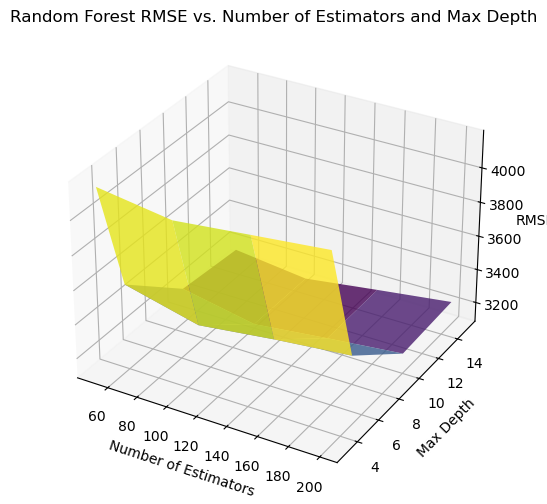

Optimal Number of Estimators: 100
Optimal Max Depth: 15
Optimal RMSE on Test Set: 3108.03671738526


In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

n_estimators_range = [50, 100, 150, 200]
max_depth_range = [3, 5, 10, 15]

rmse_grid = np.zeros((len(n_estimators_range), len(max_depth_range)))

for i, n_estimators in enumerate(n_estimators_range):
    for j, max_depth in enumerate(max_depth_range):
        rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
        rf.fit(train_X, train_y)

        predictions_rf = rf.predict(test_X)

        rmse_grid[i, j] = np.sqrt(mean_squared_error(test_y, predictions_rf))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(n_estimators_range, max_depth_range)
Z = rmse_grid.T  # Transpose for proper alignment

ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.set_xlabel('Number of Estimators')
ax.set_ylabel('Max Depth')
ax.set_zlabel('RMSE')
ax.set_title('Random Forest RMSE vs. Number of Estimators and Max Depth')
plt.show()

optimal_indices = np.unravel_index(np.argmin(rmse_grid), rmse_grid.shape)
optimal_n_estimators = n_estimators_range[optimal_indices[0]]
optimal_max_depth = max_depth_range[optimal_indices[1]]
optimal_rmse = rmse_grid[optimal_indices]

print(f"Optimal Number of Estimators: {optimal_n_estimators}")
print(f"Optimal Max Depth: {optimal_max_depth}")
print(f"Optimal RMSE on Test Set: {optimal_rmse}")

In [ ]:
'''We can make multiple observations:
1.	General Trend:
	•	RMSE decreases (indicating better model performance) as the number of estimators (n_estimators) increases and as the maximum depth (max_depth) becomes larger.
2.	Diminishing Returns:
	•	Beyond a certain point, increasing n_estimators or max_depth provides little improvement in RMSE, suggesting that further increases in model complexity may lead to overfitting or unnecessary computational cost.
3.	Optimal Region:
	•	The minimum RMSE (valley in the plot) appears when both n_estimators and max_depth are relatively high. This indicates the optimal combination of these parameters for this dataset.
4.	Balance Between Parameters:
	•	Higher max_depth allows trees to model more complex relationships, but overly deep trees can overfit.
	•	Increasing n_estimators stabilizes the model’s predictions by averaging multiple trees, reducing variance.
5.	Trade-off:
	•	While increasing n_estimators and max_depth reduces RMSE initially, it also increases training time and computational cost. The goal is to identify the sweet spot where RMSE is minimized without overfitting or excessive computation.'''

##### Open-ended Research Question

Find a model that has the lowest RMSE across all the following train-test split ratios (on the provided car dataset).

- 90% Train, 10% Test
- 70% Train, 30% Test
- 50% Train, 50% Test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_model(model, X, y, train_size):
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=42)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    return rmse

X = train_x.loc[:, ~train_x.columns.duplicated()]
y = train_y

train_ratios = [0.9, 0.7, 0.5]

models = {
    "Ridge": Ridge(alpha=10),  # Tuned hyperparameter
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)  # Tuned hyperparameters
}

results = {}
for model_name, model in models.items():
    results[model_name] = []
    for ratio in train_ratios:
        rmse = evaluate_model(model, X, y, train_size=ratio)
        results[model_name].append(rmse)

for model_name, rmses in results.items():
    print(f"{model_name} RMSEs:")
    for ratio, rmse in zip(train_ratios, rmses):
        print(f"  Train-Test Ratio {int(ratio * 100)}%-{int((1 - ratio) * 100)}%: RMSE = {rmse:.2f}")

Ridge RMSEs:
  Train-Test Ratio 90%-9%: RMSE = 3785.21
  Train-Test Ratio 70%-30%: RMSE = 5075.81
  Train-Test Ratio 50%-50%: RMSE = 5164.34
Random Forest RMSEs:
  Train-Test Ratio 90%-9%: RMSE = 2635.86
  Train-Test Ratio 70%-30%: RMSE = 3154.21
  Train-Test Ratio 50%-50%: RMSE = 3461.98


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

best_model = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42)

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_squared_error')

cv_rmse_scores = np.sqrt(-cv_scores)

print("5-Fold Cross-Validation RMSE Scores:")
for fold_idx, rmse in enumerate(cv_rmse_scores, 1):
    print(f"  Fold {fold_idx}: RMSE = {rmse:.2f}")

mean_rmse = np.mean(cv_rmse_scores)
std_rmse = np.std(cv_rmse_scores)
print(f"\nMean RMSE: {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")

5-Fold Cross-Validation RMSE Scores:
  Fold 1: RMSE = 2974.64
  Fold 2: RMSE = 2554.34
  Fold 3: RMSE = 3408.66
  Fold 4: RMSE = 2399.37
  Fold 5: RMSE = 3820.16

Mean RMSE: 3031.43
Standard Deviation of RMSE: 528.16


In [ ]:
'''Fold 4 has the lowest RMSE (2399.37), indicating that the model performed best on this specific split. Fold 5 has the highest RMSE (3820.16), suggesting it encountered challenges with the test data in that fold, potentially due to an outlier or a less representative split. '''